## Домашнее задание 5

### Задание 1

In [47]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

class Account:
    
    _account_counter = 1000
    
    def __init__(self, account_holder: str, balance: float = 0):

        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным")
        
        self.holder = account_holder
        self.account_number = f"ACC-{Account._account_counter}"

        Account._account_counter += 1
        self._balance = balance
        self.operations_history = []
        self.datetime_format = '%Y-%m-%d %H:%M:%S'
        
        # Записываем операцию создания счёта
        if balance > 0:
            self.operations_history.append({
                'operation': 'Открытие счёта',
                'amount': balance,
                'balance': self._balance,
                'datetime': datetime.now().strftime(self.datetime_format),
                'status': 'success'
            })
    
    def get_balance(self) -> float:
        return self._balance
    
    def deposit(self, amount: float) -> None:
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной")
        
        self._balance += amount
        self.operations_history.append({
            'operation': 'Пополнение',
            'amount': amount,
            'balance': self._balance,
            'datetime': datetime.now().strftime(self.datetime_format),
            'status': 'success'
        })
    
    def withdraw(self, amount: float) -> None:
        if amount > self._balance:
            # фиксируем неудачную попытку
            self.operations_history.append({
                'operation': 'withdraw',
                'amount': amount,
                'balance': self._balance,
                'datetime': datetime.now().strftime(self.datetime_format),
                'status': 'fail'
            })
            raise ValueError("Недостаточно средств на счёте")

        # успешное снятие
        self._balance -= amount
        self.operations_history.append({
            'operation': 'withdraw',
            'amount': amount,
            'balance': self._balance,
            'datetime': datetime.now().strftime(self.datetime_format),
            'status': 'success'
        })
    
    def plot_history(self):
        """
        Визуализация истории операций
        """
        if not self.operations_history:
            print("История операций пуста. Нет данных для визуализации.")
            return
        
        df = pd.DataFrame(self.operations_history)
        
        plt.figure(figsize=(12, 6))
        plt.plot(df['datetime'], df['balance'], marker='o', linewidth=2, markersize=8, color="#00B3FF", markerfacecolor="#00FF37")
        plt.title(f'История изменения баланса счёта №{self.account_number}\nВладелец: {self.holder}', fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Дата и время операции', fontsize=12, fontweight='bold')
        plt.ylabel('Баланс (₽)', fontsize=12, fontweight='bold')
        plt.grid(True, alpha=0.3, linestyle='--') 
        plt.xticks(rotation=45, ha='right')
        ax = plt.gca()
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
        
        for idx, row in df.iterrows():
            plt.annotate(f'{row["balance"]:.0f}', 
                        xy=(row['datetime'], row['balance']),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=9, color="#000000")
        
        plt.tight_layout()
        plt.show()
    
    def get_history(self) -> list:
        return self.operations_history.copy()
    
    def __str__(self) -> str:
        """Строковое представление счёта"""
        return f"Счёт {self.account_number}, Владелец: {self.holder}, Баланс: {self._balance:.2f}"

Счёт ACC-1000, Владелец: Иван Иванов, Баланс: 1000.00
Счёт ACC-1001, Владелец: Мария Петрова, Баланс: 500.00
Счёт ACC-1002, Владелец: Алексей Сидоров, Баланс: 0.00

Операции со счётом Иванова
После пополнения: 4500
После снятия: 4200

История операций
{'operation': 'Открытие счёта', 'amount': 1000, 'balance': 1000, 'datetime': '2025-10-29 20:11:16', 'status': 'success'}
{'operation': 'Пополнение', 'amount': 3500, 'balance': 4500, 'datetime': '2025-10-29 20:11:16', 'status': 'success'}
{'operation': 'withdraw', 'amount': 300, 'balance': 4200, 'datetime': '2025-10-29 20:11:16', 'status': 'success'}

ВИЗУАЛИЗАЦИЯ ИСТОРИИ ОПЕРАЦИЙ


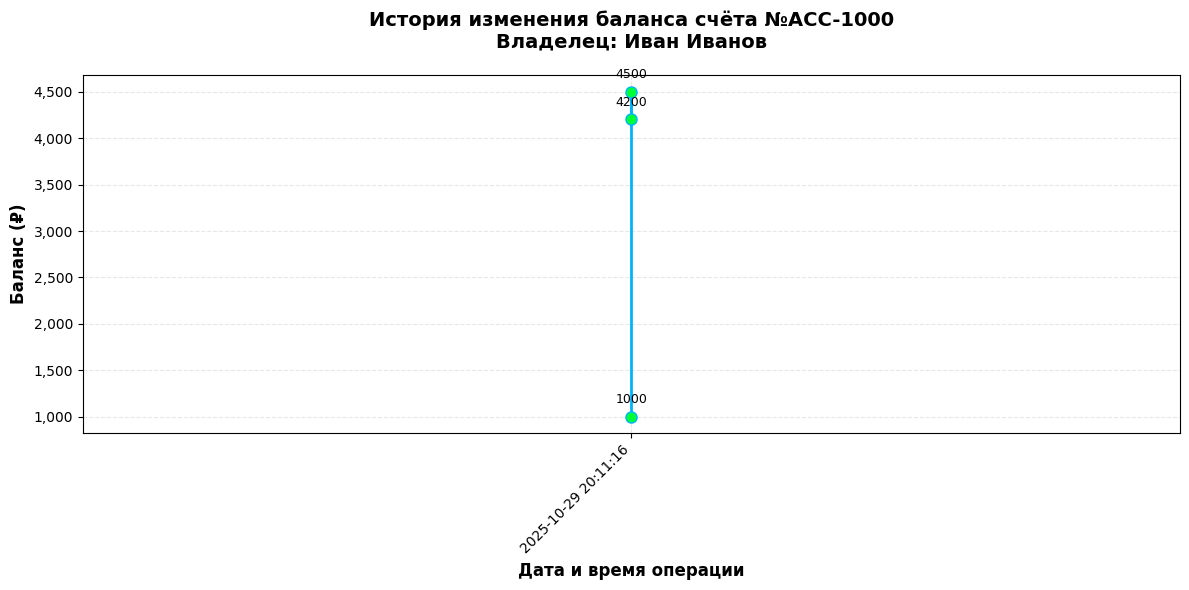

In [48]:

account1 = Account("Иван Иванов", 1000)
print(account1)

account2 = Account("Мария Петрова", 500)
print(account2)

account3 = Account("Алексей Сидоров")
print(account3)


print("\nОперации со счётом Иванова")
account1.deposit(3500)
print(f"После пополнения: {account1.get_balance()}")

account1.withdraw(300)
print(f"После снятия: {account1.get_balance()}")


print("\nИстория операций")
for operation in account1.get_history():
    print(operation)

print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ ИСТОРИИ ОПЕРАЦИЙ")
print("="*50)
account1.plot_history()

In [49]:
account_error = Account("Тест", -100)

ValueError: Начальный баланс не может быть отрицательным

In [51]:
account1.withdraw(10000)

ValueError: Недостаточно средств на счёте

In [52]:
account1.get_history()

[{'operation': 'Открытие счёта',
  'amount': 1000,
  'balance': 1000,
  'datetime': '2025-10-29 20:11:16',
  'status': 'success'},
 {'operation': 'Пополнение',
  'amount': 3500,
  'balance': 4500,
  'datetime': '2025-10-29 20:11:16',
  'status': 'success'},
 {'operation': 'withdraw',
  'amount': 300,
  'balance': 4200,
  'datetime': '2025-10-29 20:11:16',
  'status': 'success'},
 {'operation': 'withdraw',
  'amount': 10000,
  'balance': 4200,
  'datetime': '2025-10-29 20:13:23',
  'status': 'fail'}]